In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

## Simulate data

An example ground truth connectivity matrix `A`

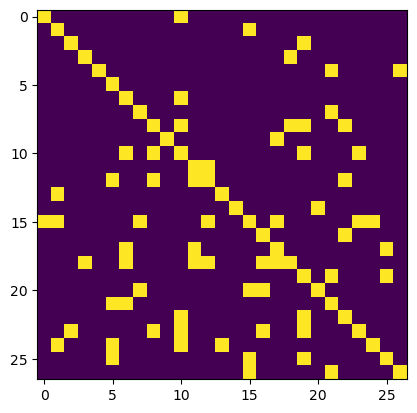

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [ ]:
%%time
metrics, N_PASTS, num = [], list(range(1, 8)), 20
for a in tqdm(range(num)):
    n_neur = np.random.randint(25, 40, 1)[0] 
    l = np.random.randint(5000, 15000, 1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1
    
    
    # simulate data
    
    A = adj_mtx(n_neur)
    noise = continuous_noise_fun(num = n_neur, l = l)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] 
                     + np.random.normal(0, 0.25, A.shape[0]) 
                                                 + noise[:, i]
    X=X.T
    
    print(f'Data {a} of {num} with {X.shape[0]} vars')
    
    # fit algorithm to data
    met = np.zeros((len(N_PASTS),4))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)
        
        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, 
                        n_lags = n_lags, temporal = True)
        gcstar.fit(X, verbose=2)
        
        # compute metrics
        gcstar.get_connectivity_matrix()
        gcstar.compute_confusion_matrix(A)
        met[k] = gcstar.compute_metrics()
    metrics.append(met)

In [4]:
for met in metrics:
    print(met)

[[0.95061728 0.72649573 0.95505618 0.05      ]
 [0.96982167 0.81904762 0.96629213 0.0296875 ]
 [0.97256516 0.83495146 0.96629213 0.0265625 ]
 [0.97530864 0.85148515 0.96629213 0.0234375 ]
 [0.98079561 0.88659794 0.96629213 0.0171875 ]
 [0.98628258 0.92473118 0.96629213 0.0109375 ]
 [0.98216735 0.90425532 0.95505618 0.0140625 ]]
[[0.94871795 0.71485944 0.96216216 0.05314371]
 [0.97764629 0.84474886 1.         0.0254491 ]
 [0.98159106 0.8685446  1.         0.02095808]
 [0.98422091 0.88516746 1.         0.01796407]
 [0.98553583 0.89371981 1.         0.01646707]
 [0.99013807 0.925      1.         0.01122754]
 [0.99013807 0.925      1.         0.01122754]]
[[0.95555556 0.73943662 0.97222222 0.04671717]
 [0.97777778 0.84375    1.         0.02525253]
 [0.98333333 0.87804878 1.         0.01893939]
 [0.98777778 0.90756303 1.         0.01388889]
 [0.99111111 0.93103448 1.         0.01010101]
 [0.99555556 0.96428571 1.         0.00505051]
 [0.99555556 0.96428571 1.         0.00505051]]
[[0.942857

In [5]:
Metrics = np.zeros((num,7,4))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

0.952022302122993

In [6]:
np.mean(Metrics,axis=0)

array([[0.9520223 , 0.73915156, 0.94021849, 0.0463896 ],
       [0.97523066, 0.84592645, 0.97465757, 0.02474248],
       [0.97893866, 0.8677986 , 0.97609707, 0.02072119],
       [0.98300568, 0.89453396, 0.97509931, 0.01596438],
       [0.98539493, 0.91118653, 0.97509931, 0.01324822],
       [0.98870177, 0.93379088, 0.97643061, 0.00966676],
       [0.99068273, 0.94864382, 0.97620868, 0.00738299]])

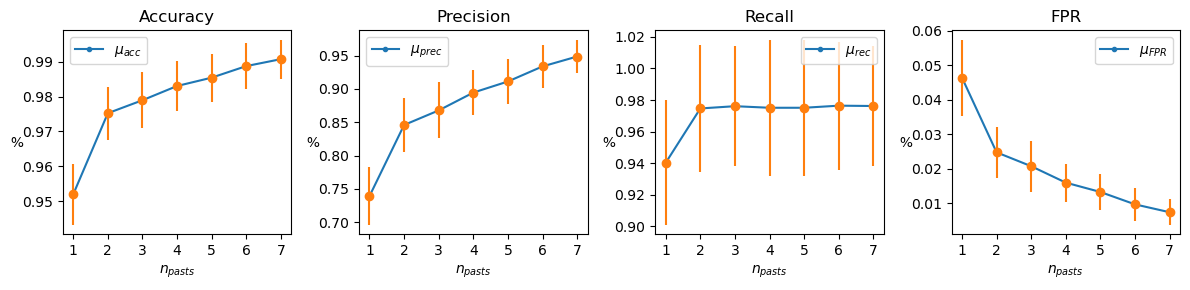

In [8]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1, 1 + Metrics.shape[1]), 
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])
    
    ax[i].errorbar(range(1, 1 + Metrics.shape[1]), 
                   np.mean(Metrics, axis = 0)[:, i], 
                   yerr = np.std(Metrics, axis = 0)[:, i], 
                   fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]), 
                     list(range(1, 1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    plt.tight_layout()